## Import the libraries

In [174]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate 
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.base import clone


from pathlib import Path


## Load the dataset

In [175]:
fh_df = pd.read_csv(r'C:\Users\jndalamia\Documents\data_science\Financial_Health_Prediction\data\financial_health.csv')
fh_df.head(10)

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target
0,ID_3CFL0U,eswatini,63.0,Yes,No,No,No,Yes,3000.0,6000.0,...,Never had,Never had,NaN,6.0,Never had,Used to have but don’t have now,NaN,Never had,Never had,Low
1,ID_XWI7G3,zimbabwe,39.0,No,Yes,Yes,No,Yes,NaN,NaN,...,NaN,NaN,No,3.0,Never had,Never had,NaN,NaN,NaN,Medium
2,ID_TY93LV,malawi,34.0,Don’t know or N/A,No,No,Don't know,Yes,30000.0,6000.0,...,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low
3,ID_9OP2C8,malawi,28.0,Yes,No,No,No,No,180000.0,60000.0,...,Never had,Never had,No,NaN,NaN,NaN,Yes,Never had,Have now,Low
4,ID_13REYS,zimbabwe,43.0,Yes,No,No,Yes,Yes,50.0,2400.0,...,NaN,NaN,No,0.0,Never had,Never had,Yes,NaN,NaN,Low
5,ID_57I1NI,lesotho,39.0,Yes,No,No,Don't know,Yes,250.0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now,Low
6,ID_L3TKQV,lesotho,25.0,Yes,Yes,No,No,No,10000.0,1350.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now,Medium
7,ID_KB700U,eswatini,44.0,Yes,Yes,No,Yes,Yes,14000.0,8500.0,...,Never had,Never had,NaN,0.0,Never had,Never had,NaN,Never had,Never had,Low
8,ID_DUQI8U,zimbabwe,34.0,Yes,No,No,Yes,Yes,150.0,1680.0,...,NaN,NaN,No,0.0,Never had,Have now,Yes,NaN,NaN,Medium
9,ID_27YH6U,eswatini,65.0,Yes,No,Yes,No,No,5000.0,9000.0,...,Never had,Have now,NaN,5.0,Never had,Have now,NaN,Never had,Never had,Medium


## Perform basic Checks

In [177]:
def basic_checks(df):
    print('-'*40, 'DataFrame Shape', '-'*40)
    print(df.shape)

    print('-'*40, 'DataFrame Head', '-'*40)
    print(df.head())

    print('-'*40, 'DataFrame Tail', '-'*40)
    print(df.tail())

    print('-'*40, 'Columns', '-'*40)
    print(df.columns.tolist())

    print('-'*40, 'DataFrame Info', '-'*40)
    print(df.info())

    print('-'*40, 'DataFrame Describe', '-'*40)
    print(df.describe(include='all').T)


In [178]:
basic_checks(fh_df)

---------------------------------------- DataFrame Shape ----------------------------------------
(9618, 39)
---------------------------------------- DataFrame Head ----------------------------------------
          ID   country  owner_age attitude_stable_business_environment  \
0  ID_3CFL0U  eswatini       63.0                                  Yes   
1  ID_XWI7G3  zimbabwe       39.0                                   No   
2  ID_TY93LV    malawi       34.0                    Don’t know or N/A   
3  ID_9OP2C8    malawi       28.0                                  Yes   
4  ID_13REYS  zimbabwe       43.0                                  Yes   

  attitude_worried_shutdown compliance_income_tax  \
0                        No                    No   
1                       Yes                   Yes   
2                        No                    No   
3                        No                    No   
4                        No                    No   

  perception_insurance_doesnt_

## Inspect the target

In [179]:
fh_df['Target'].value_counts()

Target
Low       6280
Medium    2868
High       470
Name: count, dtype: int64

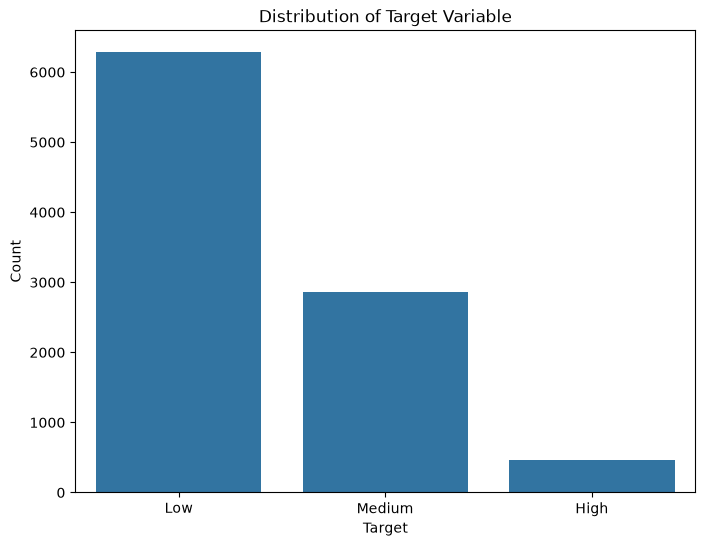

In [180]:
# Visualize the distribution of the target variable
plt.figure(figsize=(8, 6))
sns.countplot(x='Target', data=fh_df, order=fh_df["Target"].value_counts().index)
plt.title('Distribution of Target Variable')
plt.xlabel('Target')
plt.ylabel('Count')

plt.show()

## Inspect the variables

In [182]:
def_df = pd.read_csv(r'C:\Users\jndalamia\Documents\data_science\Financial_Health_Prediction\data\VariableDefinitions.csv')
def_df.head(10)

,VARIABLE_NAME,VARIABLE_DESCRIPTION
0,ID,Unique identifier for each business record
1,country,Country where the business is located (Eswatin...
2,owner_age,Age of the business owner in years
3,attitude_stable_business_environment,Owner attitude: Country will have a stable bus...
4,attitude_worried_shutdown,Owner attitude: Worried that the business will...
5,compliance_income_tax,Business complies with or acts in accordance w...
6,perception_insurance_doesnt_cover_losses,Owner perception: Insurance does not cover the...
7,perception_cannot_afford_insurance,Owner perception: Cannot afford insurance paym...
8,personal_income,Total monthly personal income of the owner bef...
9,business_expenses,Approximate monthly or annual expenses of the ...


In [183]:
def_df.shape

(39, 2)

In [185]:
def_df.to_string(index=False)

'                                                   VARIABLE_NAME                                                                VARIABLE_DESCRIPTION\n                                                              ID                                          Unique identifier for each business record\n                                                         country            Country where the business is located (Eswatini/Lesotho/Malawi/Zimbabwe)\n                                                       owner_age                                                  Age of the business owner in years\n                            attitude_stable_business_environment       Owner attitude: Country will have a stable business environment in the future\n                                       attitude_worried_shutdown                            Owner attitude: Worried that the business will shut down\n                                           compliance_income_tax            Business complies with 

## Examine missing data

In [186]:
missing = pd.DataFrame({
    'missing_count': fh_df.isnull().sum(),
    'missing_percentage': fh_df.isnull().mean() * 100
})

missing = missing.sort_values('missing_count', ascending=False)

missing

,missing_count,missing_percentage
uses_informal_lender,4489,46.672905
uses_friends_family_savings,4488,46.662508
motivation_make_more_money,4291,44.614265
funeral_insurance,4188,43.543356
medical_insurance,4188,43.543356
business_age_months,4111,42.742774
future_risk_theft_stock,4100,42.628405
has_debit_card,4003,41.619879
has_internet_banking,4003,41.619879
has_loan_account,3999,41.578291


## Identify variable types

In [187]:
fh_df.dtypes.value_counts()

str        33
float64     6
Name: count, dtype: int64

In [188]:
# categorical Columns
cat_columns = fh_df.select_dtypes(include=['object', 'str']).columns.tolist()
cat_columns

['ID',
 'country',
 'attitude_stable_business_environment',
 'attitude_worried_shutdown',
 'compliance_income_tax',
 'perception_insurance_doesnt_cover_losses',
 'perception_cannot_afford_insurance',
 'motor_vehicle_insurance',
 'has_mobile_money',
 'current_problem_cash_flow',
 'has_cellphone',
 'owner_sex',
 'offers_credit_to_customers',
 'attitude_satisfied_with_achievement',
 'has_credit_card',
 'keeps_financial_records',
 'perception_insurance_companies_dont_insure_businesses_like_yours',
 'perception_insurance_important',
 'has_insurance',
 'covid_essential_service',
 'attitude_more_successful_next_year',
 'problem_sourcing_money',
 'marketing_word_of_mouth',
 'has_loan_account',
 'has_internet_banking',
 'has_debit_card',
 'future_risk_theft_stock',
 'medical_insurance',
 'funeral_insurance',
 'motivation_make_more_money',
 'uses_friends_family_savings',
 'uses_informal_lender',
 'Target']

In [189]:
# Numerical Columns
num_columns = fh_df.select_dtypes(include=['int', 'float']).columns.tolist()
num_columns

['owner_age',
 'personal_income',
 'business_expenses',
 'business_turnover',
 'business_age_years',
 'business_age_months']

## Exploratory Data Analysis

### Target distribution

In [190]:
target_summary = fh_df['Target'].value_counts().rename_axis("Financial_Health").reset_index(name="Count")

target_summary['Percentage'] = (target_summary['Count'] / len(fh_df)) * 100
target_summary

,Financial_Health,Count,Percentage
0,Low,6280,65.294240
1,Medium,2868,29.819089
2,High,470,4.886671


### Country distribution

In [191]:
country_summary = (fh_df['country'].value_counts().rename_axis("Country").reset_index(name="Count"))
country_summary['percentage'] = (country_summary['Count']/ len(fh_df)) *100

country_summary


,Country,Count,percentage
0,eswatini,2674,27.802038
1,zimbabwe,2612,27.157413
2,malawi,2388,24.828447
3,lesotho,1944,20.212102


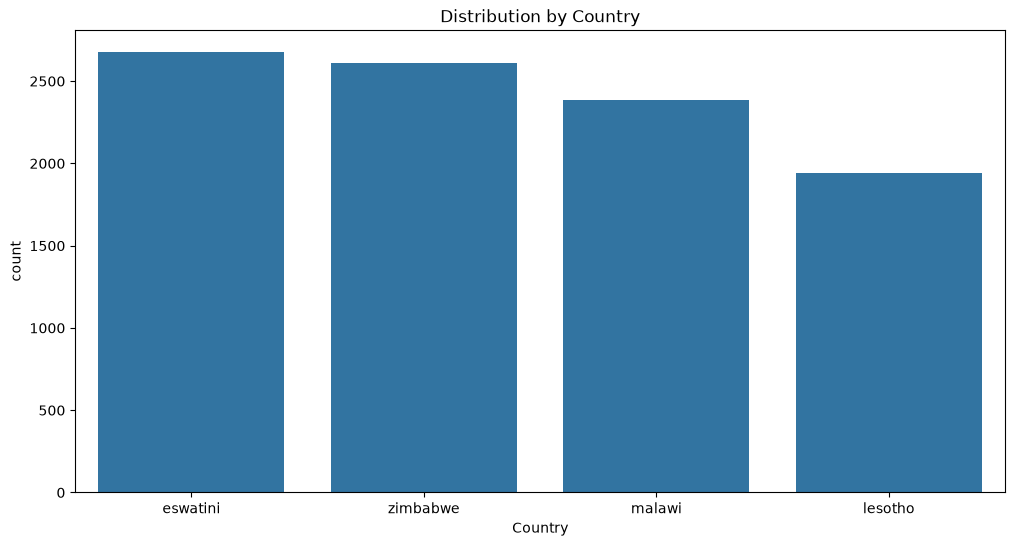

In [192]:
# Plot the Country distribution
plt.figure(figsize=(12, 6))
sns.countplot(x='country',data=fh_df)
plt.title('Distribution by Country')
plt.xlabel('Country')   
plt.show()

### Does financial health differ by country?

In [193]:
country_target = pd.crosstab(fh_df['country'], fh_df['Target'])
country_target

Target,High,Low,Medium
country,,,
eswatini,307,1375,992
lesotho,6,1174,764
malawi,96,1940,352
zimbabwe,61,1791,760


In [194]:
# Percentage of each target class by country
country_target = pd.crosstab(fh_df['country'], fh_df['Target'], normalize='index') * 100
country_target.round(2)  # Round to 2 decimal places for better readability


Target,High,Low,Medium
country,,,
eswatini,11.48,51.42,37.10
lesotho,0.31,60.39,39.30
malawi,4.02,81.24,14.74
zimbabwe,2.34,68.57,29.10


### Visualize financial health by country

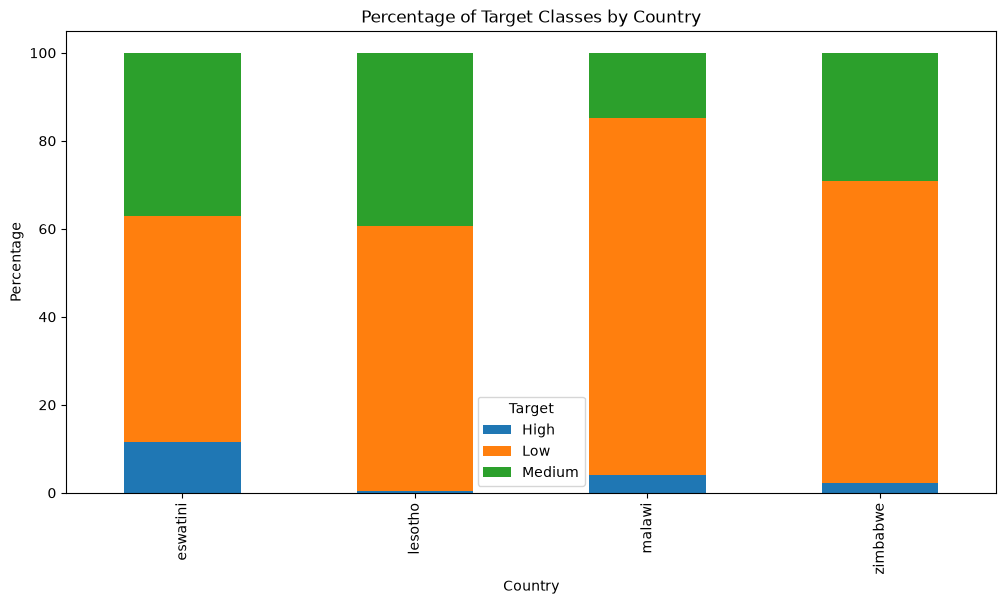

In [195]:
country_target.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Percentage of Target Classes by Country')
plt.xlabel('Country')
plt.ylabel('Percentage')
plt.legend(title='Target')
plt.show()

### Numerical Variables

In [196]:
# Summary Statistics
fh_df[num_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
owner_age,9618.0,4.170534e+01,1.331401e+01,18.0,32.0,40.0,50.0,103.0
personal_income,9509.0,2.627345e+05,2.566268e+06,0.0,300.0,2000.0,25000.0,150000000.0
business_expenses,9389.0,4.583838e+05,6.184746e+06,0.0,700.0,3000.0,25000.0,500000000.0
business_turnover,9402.0,1.348210e+06,8.804741e+06,0.0,1500.0,6000.0,50000.0,420000000.0
business_age_years,9366.0,7.030536e+00,7.650349e+00,0.0,2.0,4.0,10.0,60.0
business_age_months,5507.0,3.636281e+00,3.386488e+00,0.0,0.0,3.0,6.0,11.0


#### Distribution

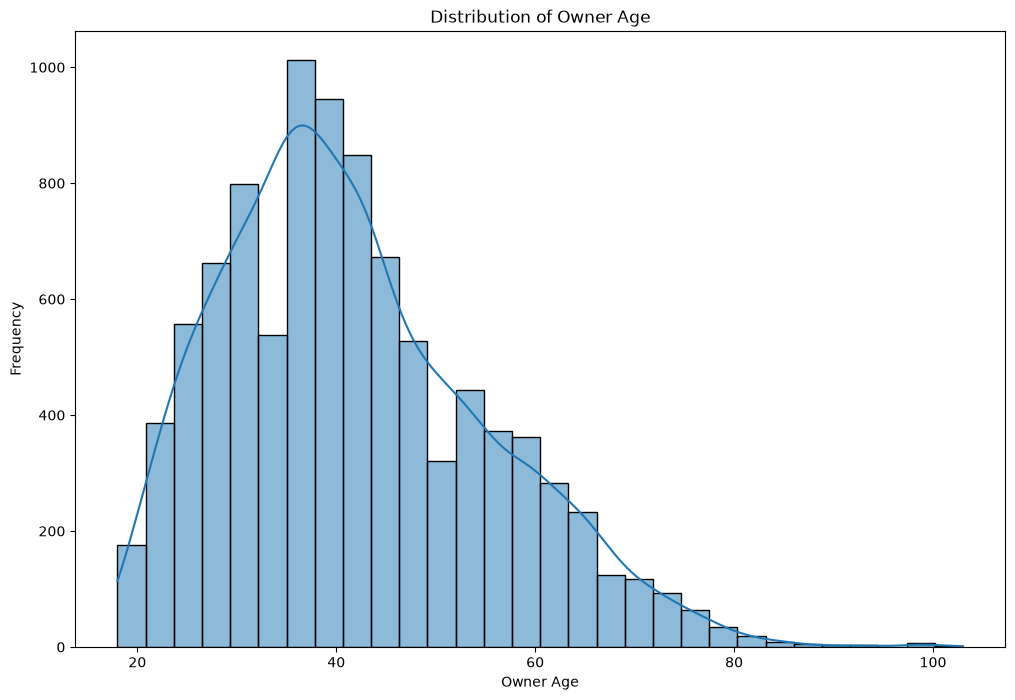

In [197]:
# Owner Age

plt.figure(figsize=(12, 8))

sns.histplot(data = fh_df, x='owner_age', bins=30, kde=True)
plt.title('Distribution of Owner Age')
plt.xlabel('Owner Age')
plt.ylabel('Frequency')
plt.show()

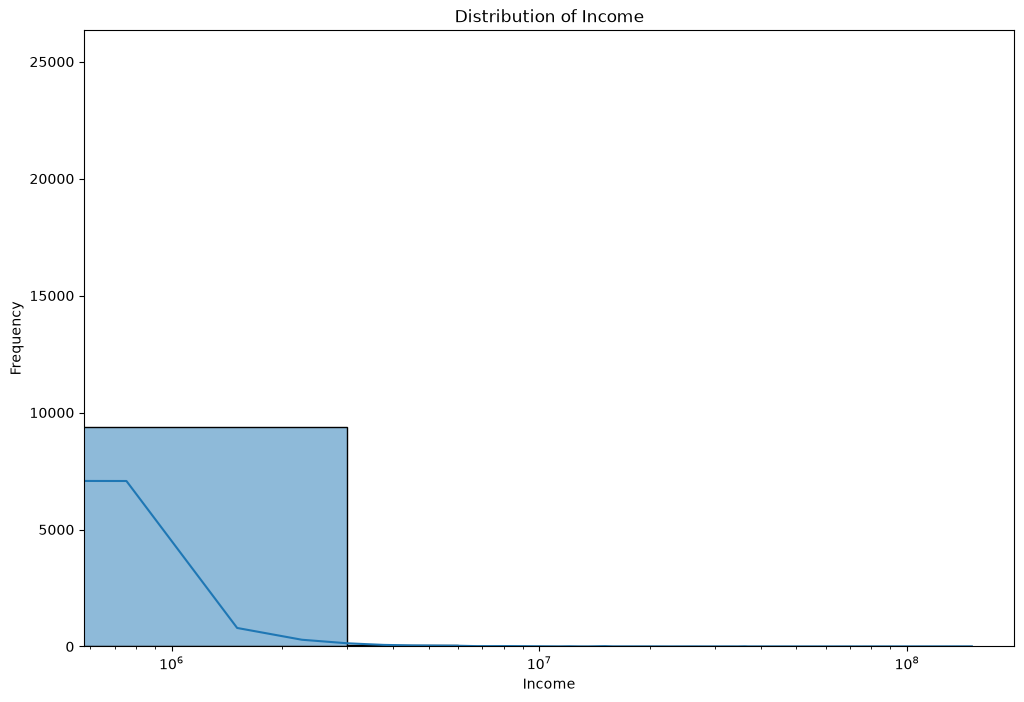

In [198]:
# Income Distribution

plt.figure(figsize=(12, 8))
sns.histplot(data = fh_df, x='personal_income', bins=50, kde=True)   
plt.xscale('log')  # Set x-axis to logarithmic scale for better visualization   
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

#### Personal income vs Target boxplot

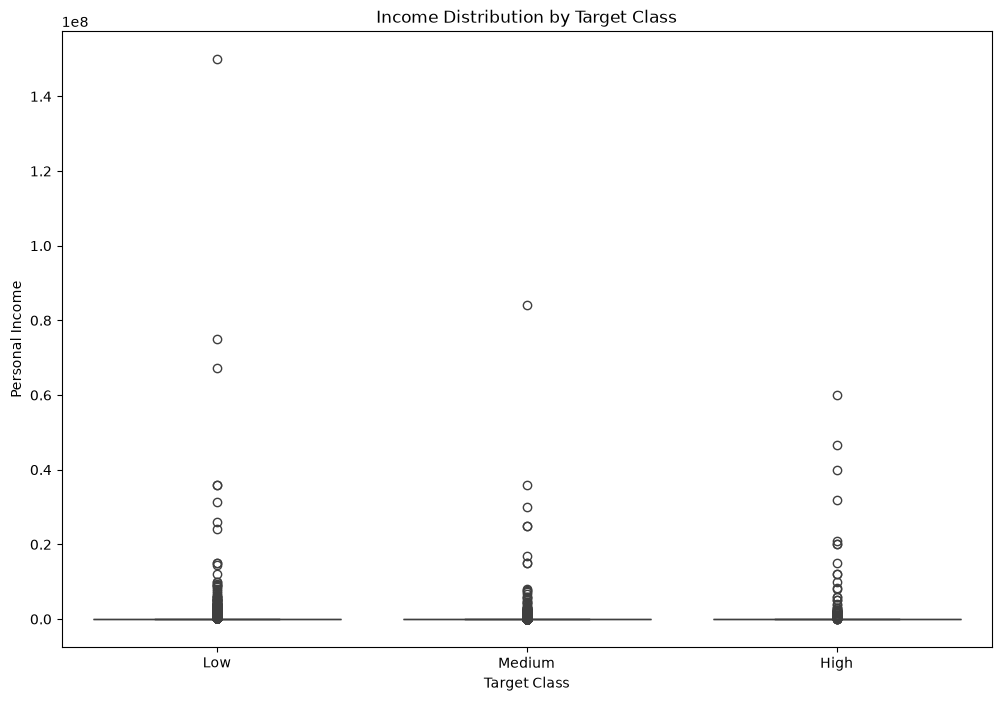

In [199]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=fh_df, x='Target', y='personal_income', order=["Low", "Medium", "High"])
plt.title('Income Distribution by Target Class')
plt.xlabel('Target Class')
plt.ylabel('Personal Income')
plt.show()

#### Business turnover vs Target boxplot

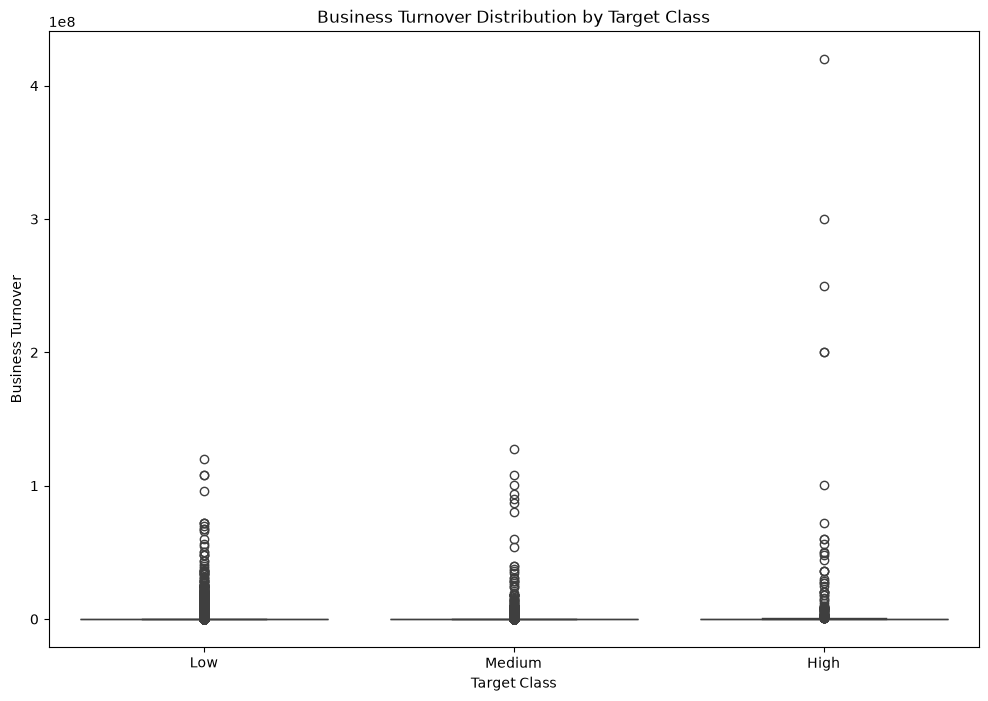

In [200]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=fh_df, x='Target', y='business_turnover', order=["Low", "Medium", "High"])
plt.title('Business Turnover Distribution by Target Class')
plt.xlabel('Target Class')
plt.ylabel('Business Turnover')
plt.show()

#### Business expenses vs Target boxplot

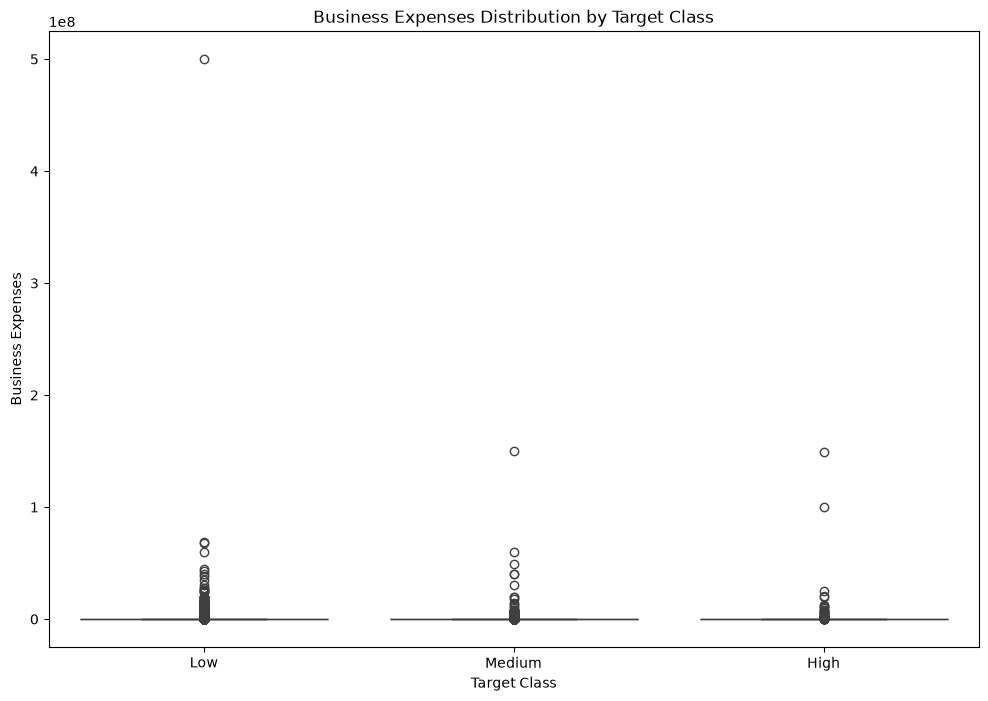

In [201]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=fh_df, x='Target', y='business_expenses', order=['Low', 'Medium', "High"])
plt.title('Business Expenses Distribution by Target Class')
plt.xlabel('Target Class')
plt.ylabel('Business Expenses')
plt.show()

In [202]:
fh_df[
    ["business_age_years", "business_age_months"]
].head(20)

,business_age_years,business_age_months
0,14.0,6.0
1,15.0,3.0
2,5.0,NaN
3,1.0,NaN
4,3.0,0.0
5,0.0,NaN
6,7.0,NaN
7,1.0,0.0
8,5.0,0.0
9,20.0,5.0


## Categorical EDA

### Define the categorical variables correctly

In [204]:
categorical_columns = fh_df.select_dtypes(include=['object', 'str']).columns.tolist()
categorical_columns.remove('ID')
categorical_columns.remove('Target')
print('Number of Categorical variables:', len(categorical_columns))

Number of Categorical variables: 31


In [205]:
fh_df['has_mobile_money'].value_counts()

has_mobile_money
Have now                           4876
Never had                          1842
Used to have but don't have now      82
Used to have but don’t have now      61
Don't know                            6
Name: count, dtype: int64

### Find the categories with the highest High-health percentage

In [206]:
pd.crosstab(fh_df['has_mobile_money'], fh_df['Target'], normalize='index') * 100

Target,High,Low,Medium
has_mobile_money,,,
Don't know,0.000000,83.333333,16.666667
Have now,7.034454,59.618540,33.347006
Never had,4.451683,72.747014,22.801303
Used to have but don't have now,4.878049,87.804878,7.317073
Used to have but don’t have now,8.196721,68.852459,22.950820


In [207]:
def target_by_category(column):

    result = pd.crosstab(
        fh_df[column],
        fh_df['Target'],
        normalize='index'
    ) * 100

    return result.round(2)  # Round to 2 decimal places for better readability

In [208]:
target_by_category('has_insurance')

Target,High,Low,Medium
has_insurance,,,
No,4.87,69.14,25.99
Yes,35.89,0.00,64.11


In [209]:
results = {}

for cols in categorical_columns:
    result = pd.crosstab(
        fh_df[cols],
        fh_df['Target'],
        normalize='index'
    ) * 100

    results[cols] = result.round(2)  # Round to 2 decimal places for better readabilityprint(f"Target distribution by {cols}:")

display(results)

{'country': Target     High    Low  Medium
 country                       
 eswatini  11.48  51.42   37.10
 lesotho    0.31  60.39   39.30
 malawi     4.02  81.24   14.74
 zimbabwe   2.34  68.57   29.10,
 'attitude_stable_business_environment': Target                                High    Low  Medium
 attitude_stable_business_environment                     
 Don’t know or N/A                     3.64  76.65   19.70
 No                                    4.73  67.48   27.78
 Yes                                   5.24  61.74   33.02,
 'attitude_worried_shutdown': Target                     High    Low  Medium
 attitude_worried_shutdown                     
 Don’t know or N/A          5.06  67.51   27.43
 No                         5.27  62.06   32.67
 Yes                        4.25  70.38   25.37,
 'compliance_income_tax': Target                  High    Low  Medium
 compliance_income_tax                      
 Don’t know              1.76  75.07   23.17
 No                      3.17 

In [210]:
results = []

for cols in categorical_columns:
    result = pd.crosstab(
        fh_df[cols],
        fh_df['Target'],
        normalize='index'
    ) * 100

    counts = fh_df[cols].value_counts(dropna=False)  # Get counts for each category

    if 'High' in result.columns:
         for category in result.index:
              results.append({
                   'variable': cols,
                   'Category': category,
                   'Count': counts.get(category, 0),  # Get the count for the category, default to 0 if not found
                   'High_Percentage': result.loc[category, 'High']
              })
            
high_health_summary = pd.DataFrame(results)

In [211]:
high_health_summary.head(20)

,variable,Category,Count,High_Percentage
0,country,eswatini,2674,11.480927
1,country,lesotho,1944,0.308642
2,country,malawi,2388,4.020101
3,country,zimbabwe,2612,2.335375
4,attitude_stable_business_environment,Don’t know or N/A,1345,3.643123
5,attitude_stable_business_environment,No,2451,4.732762
6,attitude_stable_business_environment,Yes,5820,5.240550
7,attitude_worried_shutdown,Don’t know or N/A,237,5.063291
8,attitude_worried_shutdown,No,5804,5.272226
9,attitude_worried_shutdown,Yes,3575,4.251748


In [212]:
high_health_summary[high_health_summary['Count']>=50].sort_values('High_Percentage', ascending=False).head(20)

,variable,Category,Count,High_Percentage
44,has_credit_card,Have now,281,56.227758
77,has_loan_account,Have now,436,41.513761
63,has_insurance,Yes,287,35.888502
21,motor_vehicle_insurance,Have now,297,30.976431
83,has_internet_banking,Have now,550,23.636364
96,medical_insurance,Have now,404,23.514851
118,uses_informal_lender,Used to have but don’t have now,307,20.521173
101,funeral_insurance,Have now,1608,19.900498
13,compliance_income_tax,Yes,1252,16.773163
88,has_debit_card,Have now,1438,16.411683


## Missing Values

### Create a missing-value summary

In [213]:
missing = pd.DataFrame({
    'Missing': fh_df.isnull().sum(),
    'Missing_Percentage': fh_df.isnull().mean() * 100
})

missing = missing.sort_values('Missing', ascending=False)

missing.round(2)

,Missing,Missing_Percentage
uses_informal_lender,4489,46.67
uses_friends_family_savings,4488,46.66
motivation_make_more_money,4291,44.61
funeral_insurance,4188,43.54
medical_insurance,4188,43.54
business_age_months,4111,42.74
future_risk_theft_stock,4100,42.63
has_debit_card,4003,41.62
has_internet_banking,4003,41.62
has_loan_account,3999,41.58


In [214]:
# variables with missing values only
missing[missing['Missing'] > 0].round(2)

,Missing,Missing_Percentage
uses_informal_lender,4489,46.67
uses_friends_family_savings,4488,46.66
motivation_make_more_money,4291,44.61
funeral_insurance,4188,43.54
medical_insurance,4188,43.54
business_age_months,4111,42.74
future_risk_theft_stock,4100,42.63
has_debit_card,4003,41.62
has_internet_banking,4003,41.62
has_loan_account,3999,41.58


### Separate numerical and categorical missingness

In [215]:
# Numerical columns
numerical_columns = fh_df.select_dtypes(include=['int', 'float']).columns.tolist()

fh_df[numerical_columns].isnull().sum()

owner_age                 0
personal_income         109
business_expenses       229
business_turnover       216
business_age_years      252
business_age_months    4111
dtype: int64

In [216]:
# categorical columns
categorical_columns = fh_df.select_dtypes(include=['object', 'str']).columns.tolist()

categorical_columns.remove("ID")
categorical_columns.remove("Target")
fh_df[categorical_columns].isnull().sum()

country                                                                0
attitude_stable_business_environment                                   2
attitude_worried_shutdown                                              2
compliance_income_tax                                                  4
perception_insurance_doesnt_cover_losses                               5
perception_cannot_afford_insurance                                     5
motor_vehicle_insurance                                             2244
has_mobile_money                                                    2751
current_problem_cash_flow                                           3778
has_cellphone                                                       1944
owner_sex                                                           1944
offers_credit_to_customers                                          1946
attitude_satisfied_with_achievement                                 1946
has_credit_card                                    

### Missingness vs Target

In [217]:
def check_missing_target(column):

    result = pd.crosstab(
        fh_df[column].isnull(),
        fh_df['Target'],
        normalize='index'
    ) * 100

    return result.round(2)  # Round to 2 decimal places for better readability

In [218]:
check_missing_target("has_loan_account")

Target,High,Low,Medium
has_loan_account,,,
False,7.17,66.93,25.89
True,1.68,62.99,35.33


In [219]:
results = {}

for cols in categorical_columns:
    result = pd.crosstab(
        fh_df[cols].isnull(),
        fh_df['Target'],
        normalize='index'
    ) * 100

    results[cols] = result.round(2) 

display(results)

{'country': Target   High    Low  Medium
 country                     
 False    4.89  65.29   29.82,
 'attitude_stable_business_environment': Target                                High     Low  Medium
 attitude_stable_business_environment                      
 False                                 4.89   65.29   29.83
 True                                  0.00  100.00    0.00,
 'attitude_worried_shutdown': Target                     High     Low  Medium
 attitude_worried_shutdown                      
 False                      4.89   65.29   29.83
 True                       0.00  100.00    0.00,
 'compliance_income_tax': Target                 High    Low  Medium
 compliance_income_tax                     
 False                  4.89  65.31    29.8
 True                   0.00  25.00    75.0,
 'perception_insurance_doesnt_cover_losses': Target                                    High    Low  Medium
 perception_insurance_doesnt_cover_losses                     
 False             

In [220]:
pd.crosstab(fh_df['business_age_months'].isnull(), fh_df['business_age_years'].isnull())

business_age_years,False,True
business_age_months,,
False,5280,227
True,4086,25


# Machine Learning

In [221]:
# Prepare the dataset

ml_df = fh_df.copy()

ml_df.shape

(9618, 39)

In [222]:
# Remove ID column as it is not needed for modeling

ml_df = ml_df.drop(columns=['ID'])

In [150]:
print(ml_df.shape)
print(ml_df.columns.tolist())

(9618, 38)
['country', 'owner_age', 'attitude_stable_business_environment', 'attitude_worried_shutdown', 'compliance_income_tax', 'perception_insurance_doesnt_cover_losses', 'perception_cannot_afford_insurance', 'personal_income', 'business_expenses', 'business_turnover', 'business_age_years', 'motor_vehicle_insurance', 'has_mobile_money', 'current_problem_cash_flow', 'has_cellphone', 'owner_sex', 'offers_credit_to_customers', 'attitude_satisfied_with_achievement', 'has_credit_card', 'keeps_financial_records', 'perception_insurance_companies_dont_insure_businesses_like_yours', 'perception_insurance_important', 'has_insurance', 'covid_essential_service', 'attitude_more_successful_next_year', 'problem_sourcing_money', 'marketing_word_of_mouth', 'has_loan_account', 'has_internet_banking', 'has_debit_card', 'future_risk_theft_stock', 'business_age_months', 'medical_insurance', 'funeral_insurance', 'motivation_make_more_money', 'uses_friends_family_savings', 'uses_informal_lender', 'Target'

### Separate X and y

In [223]:
X = ml_df.drop(columns=['Target'])
y= ml_df['Target']

In [224]:
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (9618, 37)
y shape: (9618,)


### Train/Test Split

In [225]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [226]:
# Check the shapes

print('X_train Shape and X_test Shape:', X_train.shape, X_test.shape)
print('y_train Shape and y_test Shape:', y_train.shape, y_test.shape)


X_train Shape and X_test Shape: (7694, 37) (1924, 37)
y_train Shape and y_test Shape: (7694,) (1924,)


In [227]:
# Confirm stratification worked
print('Training target distribution:', y_train.value_counts(normalize=True).round(3)*100)
print('\nTest target distribution:', y_test.value_counts(normalize=True).round(3)*100)

Training target distribution: Target
Low       65.3
Medium    29.8
High       4.9
Name: proportion, dtype: float64

Test target distribution: Target
Low       65.3
Medium    29.8
High       4.9
Name: proportion, dtype: float64


### Build the Preprocessing Pipeline
### Numerical preprocessing

In [228]:
# Create Imputer for numerical columns using median strategy
numeric_imputer = SimpleImputer(strategy='median')

# Create Scaler for numerical columns
numeric_scaler = StandardScaler()

# Combine the Imputer and scaler into a pipeline for numerical columns
numeric_pipeline = Pipeline([
    ('imputer', numeric_imputer),
    ('scaler', numeric_scaler)
])


### Categorical preprocessing

In [229]:
# Create Imputer for categorical columns using constant strategy (filling missing values with 'Missing')
categorical_imputer = SimpleImputer(strategy='constant', fill_value='missing')

# Encoder for categorical columns
encoder = OneHotEncoder(handle_unknown='ignore')

# Combine the Imputer and encoder into a pipeline for categorical columns
categorical_pipeline = Pipeline([
    ('imputer', categorical_imputer),
    ('encoder', encoder)
])


In [53]:
# Combine everything with ColumnTransformer
preprocessor = ColumnTransformer([
    ('numerical', numeric_pipeline, numerical_columns),
    ('categorical', categorical_pipeline, categorical_columns)
])

In [54]:
print(preprocessor)

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['owner_age', 'personal_income',
                                  'business_expenses', 'business_turnover',
                                  'business_age_years',
                                  'business_age_months']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant'))...
                                  'perception_insurance_important',
                                  'has_insurance', 'covid_essential_service',
                                  'attit

### First Machine Learning Model
First model will be Logistic Regression to establish a baseline first.

In [55]:
# Instantiate the model
logistic_model = LogisticRegression(max_iter=1000)

# Create the ML pipeline
logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', logistic_model)
]) 

# Train the model
logistic_pipeline.fit(X_train, y_train)

# Make predictions
y_pred = logistic_pipeline.predict(X_test)

print(y_pred[:20])

['Low' 'Low' 'Low' 'Medium' 'Medium' 'Medium' 'Low' 'Low' 'Medium' 'Low'
 'Medium' 'Low' 'Low' 'Low' 'Low' 'Low' 'Medium' 'Medium' 'Low' 'Low']


#### Comparison

In [56]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head(20))

    Actual Predicted
0      Low       Low
1      Low       Low
2      Low       Low
3     High    Medium
4   Medium    Medium
5     High    Medium
6      Low       Low
7      Low       Low
8   Medium    Medium
9      Low       Low
10  Medium    Medium
11     Low       Low
12  Medium       Low
13     Low       Low
14     Low       Low
15     Low       Low
16     Low    Medium
17  Medium    Medium
18  Medium       Low
19     Low       Low


#### Accuracy

In [57]:
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy', accuracy)

Accuracy 0.8653846153846154


#### Classification Report

In [58]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.81      0.55      0.66        94
         Low       0.87      0.98      0.92      1256
      Medium       0.86      0.68      0.76       574

    accuracy                           0.87      1924
   macro avg       0.85      0.73      0.78      1924
weighted avg       0.86      0.87      0.86      1924



#### Macro F1

In [59]:
macro_f1 = f1_score(y_test, y_pred, average='macro')
print('Macro F1: ', macro_f1)

Macro F1:  0.7779472334342876


In [60]:
# weighted F1
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
print('Weighted F1:', weighted_f1)

Weighted F1: 0.8581736034152045


__Baseline Summary__

In [61]:
print('Baseline Model Performance')

print('Accuracy:', round(accuracy,4))
print('Macro F1:', round(macro_f1,4))
print('Weighte F1:', round(weighted_f1, 4))


Baseline Model Performance
Accuracy: 0.8654
Macro F1: 0.7779
Weighte F1: 0.8582


#### Confusion Matrix

In [62]:
cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
print(cm)

[[1225   30    1]
 [ 175  388   11]
 [   7   35   52]]


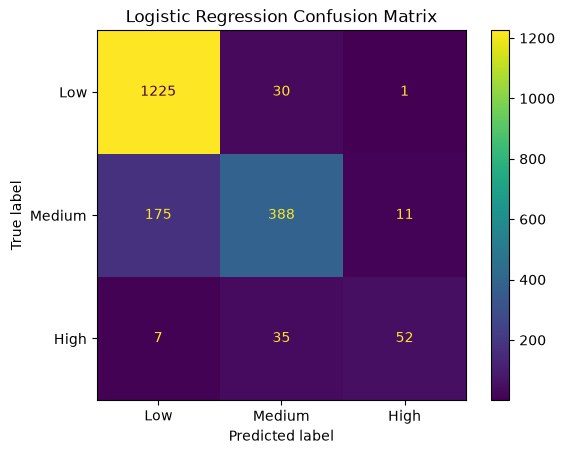

In [63]:
# Visualize the confusion matrix
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High']).plot()

plt.title('Logistic Regression Confusion Matrix')
plt.show()

## Second model
__Balanced Logistic Regression__

In [64]:
# Instantiate the model
logistic_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')

# New Pipeline
logistic_balanced_pipeline = Pipeline([
    ('Preprocessor', preprocessor),
    ('Model', logistic_balanced)
])

# Train
logistic_balanced_pipeline.fit(X_train, y_train)

# Predict
y_pred_balanced = logistic_balanced_pipeline.predict(X_test)

# Comparison
comparison_balanced = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_balanced
})

print(comparison_balanced.head(20))


    Actual Predicted
0      Low       Low
1      Low       Low
2      Low       Low
3     High      High
4   Medium      High
5     High      High
6      Low       Low
7      Low    Medium
8   Medium    Medium
9      Low       Low
10  Medium    Medium
11     Low       Low
12  Medium    Medium
13     Low       Low
14     Low       Low
15     Low       Low
16     Low    Medium
17  Medium    Medium
18  Medium    Medium
19     Low       Low


#### Evaluate

In [66]:
print(classification_report(y_test, y_pred_balanced))

balanced_accuracy = accuracy_score(y_test, y_pred_balanced)
print('Accuracy', round(balanced_accuracy, 4))

balanced_macro_f1 = f1_score(y_test, y_pred_balanced, average='macro')
print('Macro F1', round(balanced_macro_f1, 4))

balanced_weighted_f1 = f1_score(y_test, y_pred_balanced, average='weighted')
print('Weighted F1', round(balanced_weighted_f1, 4))


              precision    recall  f1-score   support

        High       0.51      0.78      0.61        94
         Low       0.92      0.87      0.89      1256
      Medium       0.70      0.72      0.71       574

    accuracy                           0.82      1924
   macro avg       0.71      0.79      0.74      1924
weighted avg       0.83      0.82      0.82      1924

Accuracy 0.8181
Macro F1 0.737
Weighted F1 0.8225


In [67]:
# Confusion Matrix

cm_balanced = confusion_matrix(y_test, y_pred_balanced, labels=['Low', 'Medium', 'High'])
print(cm_balanced)

[[1090  163    3]
 [  95  411   68]
 [   5   16   73]]


## Third Model
__Random Forest__

In [68]:
# Instantiate the model
random_forest = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=1)

# Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', random_forest)
])

# Train the model
rf_pipeline.fit(X_train, y_train)

# Predict
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluate
print('Classification report\n',classification_report(y_test, y_pred_rf))

print('Accuracy\n', accuracy_score(y_test, y_pred_rf))

print('Macro F1\n', f1_score(y_test, y_pred_rf, average='macro'))

print('Weighted F1\n', f1_score(y_test, y_pred_rf, average='weighted'))



Classification report
               precision    recall  f1-score   support

        High       0.93      0.54      0.68        94
         Low       0.88      0.97      0.92      1256
      Medium       0.85      0.70      0.77       574

    accuracy                           0.87      1924
   macro avg       0.88      0.74      0.79      1924
weighted avg       0.87      0.87      0.86      1924

Accuracy
 0.8705821205821206
Macro F1
 0.7910897608072417
Weighted F1
 0.8640608095790815


In [69]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=['Low', 'Medium', 'High'])
print(cm_rf)

[[1223   33    0]
 [ 169  401    4]
 [   5   38   51]]


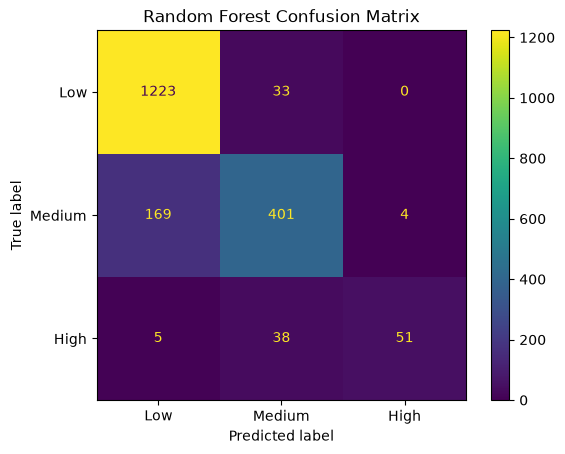

In [70]:
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Low', 'Medium', 'High']).plot()

plt.title('Random Forest Confusion Matrix')
plt.show()

In [71]:
# Extract Model
rf_model = rf_pipeline.named_steps['model']

In [72]:
# Get Feature names
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
print(len(feature_names))

155


In [73]:
# Create importance table
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

print(feature_importance.sort_values(by='Importance', ascending=False).head(20))

                                               Feature  Importance
133            categorical__funeral_insurance_Have now    0.145621
134           categorical__funeral_insurance_Never had    0.069331
1                           numerical__personal_income    0.039550
3                         numerical__business_turnover    0.038504
2                         numerical__business_expenses    0.037473
0                                 numerical__owner_age    0.034727
4                        numerical__business_age_years    0.028159
104             categorical__has_loan_account_Have now    0.026940
143  categorical__uses_friends_family_savings_Have now    0.026144
62               categorical__has_credit_card_Have now    0.023313
127            categorical__medical_insurance_Have now    0.019949
85                      categorical__has_insurance_Yes    0.016171
63              categorical__has_credit_card_Never had    0.015038
105            categorical__has_loan_account_Never had    0.01

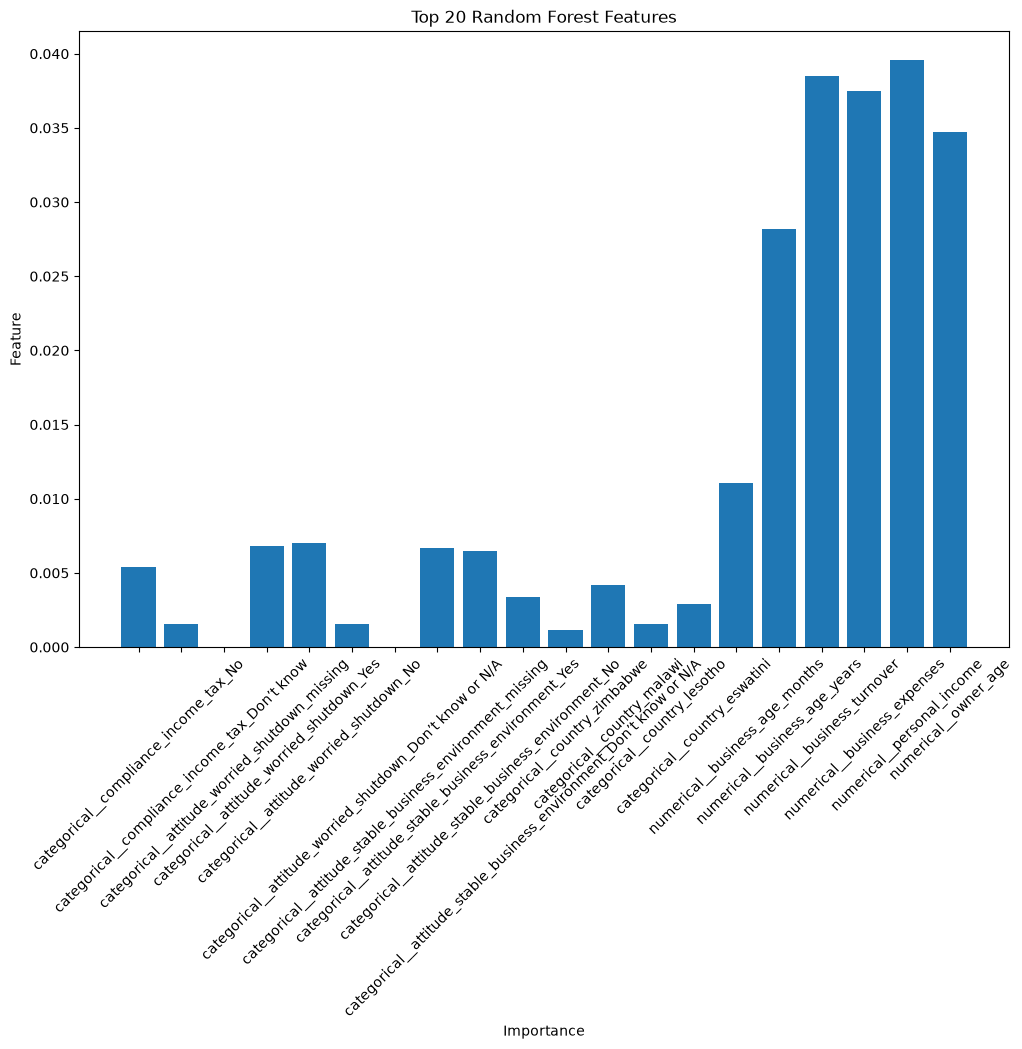

In [74]:
# Create Chart
top_features = feature_importance.head(20)

plt.figure(figsize=(12,8))
plt.bar(top_features['Feature'], top_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Random Forest Features')
plt.xticks(rotation=45)
plt.gca().invert_xaxis()
plt.show()

In [75]:
print(fh_df["funeral_insurance"].value_counts(dropna=False))

print(
    pd.crosstab(
        fh_df["funeral_insurance"],
        fh_df["Target"],
        normalize="index"
    ).round(3)
)

print(
    pd.crosstab(
        fh_df["funeral_insurance"].isna(),
        fh_df["Target"],
        normalize="index"
    ).round(3)
)

funeral_insurance
NaN                                4188
Never had                          3615
Have now                           1608
Used to have but don't have now     148
Used to have but don’t have now      33
Don't know                           26
Name: count, dtype: int64
Target                            High    Low  Medium
funeral_insurance                                    
Don't know                       0.077  0.885   0.038
Have now                         0.199  0.000   0.801
Never had                        0.025  0.834   0.141
Used to have but don't have now  0.061  0.804   0.135
Used to have but don’t have now  0.000  0.606   0.394
Target              High    Low  Medium
funeral_insurance                      
False              0.078  0.585   0.337
True               0.011  0.741   0.247


In [76]:
print(fh_df["has_loan_account"].value_counts(dropna=False))

print(
    pd.crosstab(
        fh_df["has_loan_account"],
        fh_df["Target"],
        normalize="index"
    ).round(3)
)

print(
    pd.crosstab(
        fh_df["has_loan_account"].isna(),
        fh_df["Target"],
        normalize="index"
    ).round(3)
)

has_loan_account
Never had                          4501
NaN                                3999
Used to have but don't have now     477
Have now                            436
Used to have but don’t have now     182
Don't know                           19
Don’t know (Do not show)              4
Name: count, dtype: int64
Target                            High    Low  Medium
has_loan_account                                     
Don't know                       0.053  0.737   0.211
Don’t know (Do not show)         0.000  0.750   0.250
Have now                         0.415  0.220   0.365
Never had                        0.044  0.709   0.247
Used to have but don't have now  0.004  0.792   0.203
Used to have but don’t have now  0.115  0.440   0.445
Target             High    Low  Medium
has_loan_account                      
False             0.072  0.669   0.259
True              0.017  0.630   0.353


In [76]:
numeric_features = preprocessor.transformers_[0][2]
categorical_features = preprocessor.transformers_[1][2]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['owner_age', 'personal_income', 'business_expenses', 'business_turnover', 'business_age_years', 'business_age_months']

Categorical features:
['country', 'attitude_stable_business_environment', 'attitude_worried_shutdown', 'compliance_income_tax', 'perception_insurance_doesnt_cover_losses', 'perception_cannot_afford_insurance', 'motor_vehicle_insurance', 'has_mobile_money', 'current_problem_cash_flow', 'has_cellphone', 'owner_sex', 'offers_credit_to_customers', 'attitude_satisfied_with_achievement', 'has_credit_card', 'keeps_financial_records', 'perception_insurance_companies_dont_insure_businesses_like_yours', 'perception_insurance_important', 'has_insurance', 'covid_essential_service', 'attitude_more_successful_next_year', 'problem_sourcing_money', 'marketing_word_of_mouth', 'has_loan_account', 'has_internet_banking', 'has_debit_card', 'future_risk_theft_stock', 'medical_insurance', 'funeral_insurance', 'motivation_make_more_money', 'uses_friends_family_savings', '

In [77]:
print(fh_df["has_loan_account"].value_counts(dropna=False))

has_loan_account
Never had                          4501
NaN                                3999
Used to have but don't have now     477
Have now                            436
Used to have but don’t have now     182
Don't know                           19
Don’t know (Do not show)              4
Name: count, dtype: int64


In [78]:
print(
    pd.crosstab(
        fh_df["has_loan_account"],
        fh_df["Target"],
        normalize="index"
    ).round(3)
)

Target                            High    Low  Medium
has_loan_account                                     
Don't know                       0.053  0.737   0.211
Don’t know (Do not show)         0.000  0.750   0.250
Have now                         0.415  0.220   0.365
Never had                        0.044  0.709   0.247
Used to have but don't have now  0.004  0.792   0.203
Used to have but don’t have now  0.115  0.440   0.445


In [79]:
print(
    pd.crosstab(
        fh_df["has_loan_account"].isna(),
        fh_df["Target"],
        normalize="index"
    ).round(3)
)

Target             High    Low  Medium
has_loan_account                      
False             0.072  0.669   0.259
True              0.017  0.630   0.353


In [80]:
print(fh_df["funeral_insurance"].value_counts(dropna=False))

funeral_insurance
NaN                                4188
Never had                          3615
Have now                           1608
Used to have but don't have now     148
Used to have but don’t have now      33
Don't know                           26
Name: count, dtype: int64


In [81]:
print(
    pd.crosstab(
        fh_df["funeral_insurance"],
        fh_df["Target"],
        normalize="index"
    ).round(3)
)

Target                            High    Low  Medium
funeral_insurance                                    
Don't know                       0.077  0.885   0.038
Have now                         0.199  0.000   0.801
Never had                        0.025  0.834   0.141
Used to have but don't have now  0.061  0.804   0.135
Used to have but don’t have now  0.000  0.606   0.394


In [82]:
print(
    pd.crosstab(
        fh_df["funeral_insurance"].isna(),
        fh_df["Target"],
        normalize="index"
    ).round(3)
)

Target              High    Low  Medium
funeral_insurance                      
False              0.078  0.585   0.337
True               0.011  0.741   0.247


#### clean category labels

In [83]:
# Create a copy of our data
fh_df_clean = fh_df.copy()

# Normalize curly apostrophes
for col in categorical_features:
    fh_df_clean[col] = fh_df_clean[col].str.replace(
        "’",
        "'", 
        regex=False
    )

# Check that the duplicate categories were combined
print(fh_df_clean["funeral_insurance"].value_counts(dropna=False))

print("Original shape:", fh_df.shape)
print("Cleaned shape:", fh_df_clean.shape)

funeral_insurance
NaN                                4188
Never had                          3615
Have now                           1608
Used to have but don't have now     181
Don't know                           26
Name: count, dtype: int64
Original shape: (9618, 39)
Cleaned shape: (9618, 39)


#### check the other categorical variables

In [84]:
for col in categorical_features:
    values = fh_df_clean[col].dropna().unique()

    print('\n', col)
    print(values)


 country
<StringArray>
['eswatini', 'zimbabwe', 'malawi', 'lesotho']
Length: 4, dtype: str

 attitude_stable_business_environment
<StringArray>
['Yes', 'No', 'Don't know or N/A']
Length: 3, dtype: str

 attitude_worried_shutdown
<StringArray>
['No', 'Yes', 'Don't know or N/A']
Length: 3, dtype: str

 compliance_income_tax
<StringArray>
['No', 'Yes', 'Don't know', 'Refused']
Length: 4, dtype: str

 perception_insurance_doesnt_cover_losses
<StringArray>
['No', 'Don't know', 'Yes']
Length: 3, dtype: str

 perception_cannot_afford_insurance
<StringArray>
['Yes', 'No', 'Don't know']
Length: 3, dtype: str

 motor_vehicle_insurance
<StringArray>
['Never had', 'Have now', 'Used to have but don't have now', 'Don't know']
Length: 4, dtype: str

 has_mobile_money
<StringArray>
['Have now', 'Never had', 'Used to have but don't have now', 'Don't know']
Length: 4, dtype: str

 current_problem_cash_flow
<StringArray>
['Yes', 'No', '0']
Length: 3, dtype: str

 has_cellphone
<StringArray>
['Yes', 'No'

In [85]:
# Check the target

print(fh_df_clean['Target'].value_counts())

Target
Low       6280
Medium    2868
High       470
Name: count, dtype: int64


#### Recreate X and y

In [86]:
X_clean = fh_df_clean.drop(columns=['Target', 'ID'])
y_clean = fh_df_clean['Target']

print('X shape', X_clean.shape)
print('y shape', y_clean.shape)

X shape (9618, 37)
y shape (9618,)


#### Split the cleaned data

In [87]:
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean)

print(X_test_clean.shape)
print(X_test_clean.shape)
print(y_train_clean.shape)
print(y_test_clean.shape)

(1924, 37)
(1924, 37)
(7694,)
(1924,)


#### Recreate the preprocessing pipeline

In [88]:
# Numeric Features
numeric_features = [
    'owner_age',
    'personal_income',
    'business_expenses',
    'business_turnover',
    'business_age_years',
    'business_age_months'
]


# Categorical Features
categorical_features_clean = X_clean.select_dtypes(include='object').columns.tolist()

print('Number Numerical features', len(numeric_features))
print('Number Categorical features', len(categorical_features_clean))


Number Numerical features 6
Number Categorical features 31


C:\Users\jndalamia\AppData\Local\Temp\ipykernel_26732\4226679022.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features_clean = X_clean.select_dtypes(include='object').columns.tolist()


#### Build the preprocessor

In [163]:
numeric_transformer = Pipeline(steps=[
                                ('imputer', SimpleImputer(strategy='median')),
                                ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
                                    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                                    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_clean = ColumnTransformer([
                                        ('numeric', numeric_transformer, numeric_features),
                                        ('categorical', categorical_transformer, categorical_features_clean)
])


#### Train the Random Forest

In [90]:
# Instantiate model
rf_clean = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)

In [91]:
# Pipeline
rf_pipeline_clean = Pipeline([
    ('preprocessor', preprocessor_clean),
    ('model', rf_clean)
])

# Train
rf_pipeline_clean.fit(X_train_clean, y_train_clean)

# Predict
y_pred_clean = rf_pipeline_clean.predict(X_test_clean)


#### Evaluate the new model

In [92]:
print(classification_report(y_test_clean, y_pred_clean))

accuracy_clean = accuracy_score(y_test_clean, y_pred_clean)

macro_f1_clean = f1_score(y_test_clean, y_pred_clean, average='macro')

weighted_f1_clean = f1_score(y_test_clean, y_pred_clean, average='weighted')

print('Accuracy', round(accuracy_clean, 4))
print('Macro F1', round(macro_f1_clean, 4))
print('Weighted F1', round(weighted_f1_clean, 4))

              precision    recall  f1-score   support

        High       0.87      0.64      0.74        94
         Low       0.89      0.93      0.91      1256
      Medium       0.78      0.75      0.76       574

    accuracy                           0.86      1924
   macro avg       0.85      0.77      0.80      1924
weighted avg       0.86      0.86      0.86      1924

Accuracy 0.8602
Macro F1 0.8033
Weighted F1 0.8581


In [93]:
# confusion matrix
cm_clean = confusion_matrix(y_test_clean, y_pred_clean)
print(cm_clean)

[[  60    3   31]
 [   0 1167   89]
 [   9  137  428]]


In [94]:
cm_df = pd.DataFrame(
    cm_clean, 
    index=['Actual high', 'Actual Low', 'Actual medium'],
     columns=['Predicted High', 'Predicted Low', 'Predicted medium']
)

print(cm_df)

               Predicted High  Predicted Low  Predicted medium
Actual high                60              3                31
Actual Low                  0           1167                89
Actual medium               9            137               428


#### Permutation Importance

#### Calculate Permutation Importance

In [95]:
perm = permutation_importance(rf_pipeline_clean, X_test_clean, y_test_clean, 
                              scoring='f1_macro', 
                              n_repeats=5, 
                              random_state=42, 
                              n_jobs=-1
)

In [96]:
# Put the results into a table
perm_df = pd.DataFrame({
    'feaure': X_test_clean.columns,
    'importance': perm.importances_mean
})

perm_df = perm_df.sort_values('importance', ascending=False)

print(perm_df.head(20))

                                feaure  importance
33                   funeral_insurance    0.202322
27                    has_loan_account    0.091045
18                     has_credit_card    0.076242
22                       has_insurance    0.017188
35         uses_friends_family_savings    0.012311
32                   medical_insurance    0.010362
9                    business_turnover    0.008434
29                      has_debit_card    0.007262
7                      personal_income    0.005431
4                compliance_income_tax    0.004950
6   perception_cannot_afford_insurance    0.004005
28                has_internet_banking    0.003635
11             motor_vehicle_insurance    0.003057
16          offers_credit_to_customers    0.002857
31                 business_age_months    0.002294
14                       has_cellphone    0.001625
15                           owner_sex    0.001394
8                    business_expenses    0.000955
36                uses_informal

### Cross-validation
#### RandomizedSearchCV

In [97]:
# Create parameters options
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline_clean,
    param_distributions=param_grid,
    n_iter=15,
    scoring='f1_macro',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [103]:
# Train
random_search.fit(X_train_clean, y_train_clean)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit``

In [104]:
print('Best parameters:')
print(random_search.best_params_)

print('Best Cross Validation Macro F1:')
print(random_search.best_score_)

Best parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 20}
Best Cross Validation Macro F1:
0.795689590910403


#### Evaluate the tuned model on the test set

In [151]:
best_model = random_search.best_estimator_

y_pred_tuned = best_model.predict(X_test_clean)

In [106]:
print(classification_report(y_test_clean, y_pred_tuned))

              precision    recall  f1-score   support

        High       0.74      0.68      0.71        94
         Low       0.91      0.91      0.91      1256
      Medium       0.76      0.76      0.76       574

    accuracy                           0.86      1924
   macro avg       0.80      0.78      0.79      1924
weighted avg       0.86      0.86      0.86      1924



In [107]:
accuracy_tuned = accuracy_score(y_test_clean, y_pred_tuned)

macro_f1_tuned = f1_score(y_test_clean, y_pred_tuned, average='macro')

weighted_f1_tuned = f1_score(y_test_clean, y_pred_tuned, average='weighted')

print('Accuracy:', round(accuracy_tuned, 4))
print('Macro F1:', round(macro_f1_tuned, 4))
print('Weighted:', round(weighted_f1_tuned, 4))

Accuracy: 0.856
Macro F1: 0.7929
Weighted: 0.8556


In [153]:
models['Random Forest (tuned)'] = random_search.best_estimator_.named_steps['model']

### Run multiple models in one experiment

In [164]:
from sklearn.pipeline import Pipeline


models = {
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),

    'KNN': KNeighborsClassifier(
        n_neighbors=5
    ),

    'SVM': SVC(
        class_weight='balanced',
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    ),

    'Extra Trees': ExtraTreesClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
}

results = []

trained_models = {}

for name, model in models.items():

    print(f'\nTraining {name}...')

    pipeline = Pipeline([
        ('preprocessor', preprocessor_clean),
        ('model', model)
    ])

    #train
    pipeline.fit(X_train_clean, y_train_clean)

    #predict
    predictions = pipeline.predict(X_test_clean)

    #metrics
    accuracy = accuracy_score(y_test_clean, predictions)

    macro_f1 = f1_score(y_test_clean, predictions, average='macro')

    weighted_f1 = f1_score(y_test_clean, predictions, average='weighted')

    #store model
    trained_models[name] = pipeline

    #store results
    results.append({
        'Model': name,
        'Accuracy': round(accuracy, 4),
        'Macro F1': round(macro_f1, 4),
        'Weighted F1': round(weighted_f1, 4)
    })

    print(f'Accuracy: {accuracy:.4f}')
    print(f'Nacro F1: {macro_f1:.4f}')
    print(f'Weighted F1: {weighted_f1:.4f}')

    #Comparison table

results_df = pd.DataFrame(results)

result_df = results_df.sort_values(
    by='Macro F1',
    ascending=False
)

result_df



Training Decision Tree...
Accuracy: 0.8254
Nacro F1: 0.7491
Weighted F1: 0.8255

Training KNN...
Accuracy: 0.7713
Nacro F1: 0.6288
Weighted F1: 0.7521

Training SVM...
Accuracy: 0.8321
Nacro F1: 0.7610
Weighted F1: 0.8356

Training Gradient Boosting...
Accuracy: 0.8758
Nacro F1: 0.8064
Weighted F1: 0.8687

Training Extra Trees...
Accuracy: 0.8701
Nacro F1: 0.7973
Weighted F1: 0.8652


,Model,Accuracy,Macro F1,Weighted F1
3,Gradient Boosting,0.8758,0.8064,0.8687
4,Extra Trees,0.8701,0.7973,0.8652
2,SVM,0.8321,0.7610,0.8356
0,Decision Tree,0.8254,0.7491,0.8255
1,KNN,0.7713,0.6288,0.7521


In [155]:
best_model_name = result_df.iloc[0]['Model']
print(f"Best model by Macro F1: {best_model_name}")
best_pipeline = trained_models[best_model_name]

Best model by Macro F1: Gradient Boosting


#### Final Model Interpretation

In [166]:
# Get the final model
final_model = clone(best_pipeline)

#### Train the Final Model on the Complete Dataset
Create the final pipeline

In [167]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

In [168]:
# Train on the complete training data

final_model.fit(X_clean,y_clean)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['High','Low','Medium']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](37,)","['country','owner_age','attitude_stable_business_environment',..., 'motivation_make_more_money','uses_friends_family_savings', 'uses_informal_lender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,37
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, a

In [136]:
# Load test dataset
test_data = pd.read_csv(r'C:\Users\jndalamia\Documents\data_science\Financial_Health_Prediction\data\Test.csv')

test_data.head()


,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender
0,ID_5EGLKX,zimbabwe,50.0,No,No,No,No,Yes,100.0,3600.0,...,NaN,NaN,NaN,No,8.0,Never had,Never had,NaN,NaN,NaN
1,ID_4AI7RE,lesotho,36.0,Yes,Yes,No,Yes,Yes,900.0,400.0,...,NaN,NaN,NaN,Yes,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now
2,ID_V9OB3M,lesotho,25.0,Don’t know or N/A,No,No,Don't know,Don't know,5250.0,350.0,...,Used to have but don't have now,Have now,Have now,Yes,NaN,NaN,NaN,No,Never had,Used to have but don't have now
3,ID_6OI9DI,malawi,25.0,Don’t know or N/A,Yes,No,No,Yes,485000.0,10000.0,...,Never had,Never had,Never had,Yes,NaN,NaN,NaN,Yes,Have now,Never had
4,ID_H2TN8B,lesotho,47.0,No,Yes,No,Don't know,Don't know,97.0,500.0,...,Used to have but don't have now,Have now,Have now,Yes,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now


In [137]:
print(test_data.shape)

(2405, 38)


In [138]:
print(test_data.columns.tolist())

['ID', 'country', 'owner_age', 'attitude_stable_business_environment', 'attitude_worried_shutdown', 'compliance_income_tax', 'perception_insurance_doesnt_cover_losses', 'perception_cannot_afford_insurance', 'personal_income', 'business_expenses', 'business_turnover', 'business_age_years', 'motor_vehicle_insurance', 'has_mobile_money', 'current_problem_cash_flow', 'has_cellphone', 'owner_sex', 'offers_credit_to_customers', 'attitude_satisfied_with_achievement', 'has_credit_card', 'keeps_financial_records', 'perception_insurance_companies_dont_insure_businesses_like_yours', 'perception_insurance_important', 'has_insurance', 'covid_essential_service', 'attitude_more_successful_next_year', 'problem_sourcing_money', 'marketing_word_of_mouth', 'has_loan_account', 'has_internet_banking', 'has_debit_card', 'future_risk_theft_stock', 'business_age_months', 'medical_insurance', 'funeral_insurance', 'motivation_make_more_money', 'uses_friends_family_savings', 'uses_informal_lender']


In [157]:
# Clean Test data

test_data_clean = test_data.copy()
for col in categorical_features_clean:
    if col in test_data_clean.columns:
        test_data_clean[col] = test_data_clean[col].str.replace("’", "'", regex=False)


In [158]:
X_zindi_test = test_data_clean.drop(columns=['ID'])

In [159]:
X_zindi_test.shape

(2405, 37)

#### Make predictions

In [169]:
zindi_predictions = final_model.predict(X_zindi_test)

In [170]:
zindi_predictions[:10]

array(['Low', 'Low', 'Low', 'Low', 'Low', 'Medium', 'Low', 'Low',
       'Medium', 'Low'], dtype=object)

#### Check the prediction distribution

In [171]:
pd.Series(zindi_predictions).value_counts(normalize=True) * 100

Low       72.432432
Medium    23.742204
High       3.825364
Name: proportion, dtype: float64

In [231]:
submission = pd.DataFrame({
    'ID': test_data['ID'],
    'Target': zindi_predictions
})

sample_sub = pd.read_csv(r'C:\Users\jndalamia\Documents\data_science\Financial_Health_Prediction\data\SampleSubmission.csv')

assert list(submission.columns) == list(sample_sub.columns), "Column name/order mismatch"
assert len(submission) == len(sample_sub), f"Row count mismatch: {len(submission)} vs {len(sample_sub)}"
assert set(submission['ID']) == set(sample_sub['ID']), "ID values don't match the official test set"
assert set(submission['Target'].unique()) <= {'Low', 'Medium', 'High'}, "Unexpected Target label"
assert submission['Target'].isna().sum() == 0, "Found missing predictions"

submission.to_csv(r'C:\Users\jndalamia\Documents\data_science\Financial_Health_Prediction\outputs\submission.csv', index=False)
print("Submission looks valid:", submission.shape)
submission.head()

Submission looks valid: (2405, 2)


,ID,Target
0,ID_5EGLKX,Low
1,ID_4AI7RE,Low
2,ID_V9OB3M,Low
3,ID_6OI9DI,Low
4,ID_H2TN8B,Low
